## Análise de Dados — Grupo 7

Este notebook contém:

- Apresentação do Grupo 7  
- Objetivo do projeto  
- Descrição dos dados utilizados (Base TSE das UF's MG, RJ e SC) 
- Importação das bibliotecas  
- Processamento e limpeza  
- Análises exploratórias  
- Visualizações  
- Conclusões iniciais  

---
##  Integrantes do Grupo 7
- Cariane Ribeiro
- Leonardo Antonio
- Leonardo Rodrigues
  

---

##  Objetivo do Projeto
O objetivo deste trabalho é analisar os dados de votação, identificar padrões, comportamentos e possíveis insights relevantes para o estudo.

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [2]:
df_rj = pd.read_csv("../dados/detalhe_votacao_secao_2022_RJ.csv", encoding="latin1", sep=";")
df_mg = pd.read_csv("../dados/detalhe_votacao_secao_2022_MG.csv", encoding="latin1", sep=";")
df_sc = pd.read_csv("../dados/detalhe_votacao_secao_2022_SC.csv", encoding="latin1", sep=";")

df_rj.head(), df_mg.head(), df_sc.head()


(   DT_GERACAO HH_GERACAO  ANO_ELEICAO  CD_TIPO_ELEICAO    NM_TIPO_ELEICAO  \
 0  15/02/2024   15:56:11         2022                2  Eleição Ordinária   
 1  15/02/2024   15:56:11         2022                2  Eleição Ordinária   
 2  15/02/2024   15:56:11         2022                2  Eleição Ordinária   
 3  15/02/2024   15:56:11         2022                2  Eleição Ordinária   
 4  15/02/2024   15:56:11         2022                2  Eleição Ordinária   
 
    NR_TURNO  CD_ELEICAO                      DS_ELEICAO  DT_ELEICAO  \
 0         1         546  Eleições Gerais Estaduais 2022  02/10/2022   
 1         1         546  Eleições Gerais Estaduais 2022  02/10/2022   
 2         1         546  Eleições Gerais Estaduais 2022  02/10/2022   
 3         1         546  Eleições Gerais Estaduais 2022  02/10/2022   
 4         1         546  Eleições Gerais Estaduais 2022  02/10/2022   
 
   TP_ABRANGENCIA  ... NR_LOCAL_VOTACAO  \
 0              E  ...             1104   
 1        

In [3]:
df_rj["estado"] = "RJ"
df_mg["estado"] = "MG"
df_sc["estado"] = "SC"


In [4]:
df = pd.concat([df_rj, df_mg, df_sc], ignore_index=True)
df.head()


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,...,NM_LOCAL_VOTACAO,DS_LOCAL_VOTACAO_ENDERECO,DT_RECEBIMENTO_BU_HOR_TSE,DT_PRIM_TOT_PARCIAL_HOR_TSE,DS_ORIGEM_VOTO,ST_SECAO_INSTALADA,ST_SECAO_ANULADA,CD_MODELO_URNA,DS_MODELO_URNA,estado
0,15/02/2024,15:56:11,2022,2,Eleição Ordinária,1,546,Eleições Gerais Estaduais 2022,02/10/2022,E,...,ESCOLA MUNICIPAL SEBASTIAO HERCULANO DE MATOS,RUA TORRES GONCALVES 132,02/10/2022 20:19:51,02/10/2022 20:20:06,Urna Eletrônica,Sim,Não,2009,UE 2009,RJ
1,15/02/2024,15:56:11,2022,2,Eleição Ordinária,1,546,Eleições Gerais Estaduais 2022,02/10/2022,E,...,ESCOLA MUNICIPAL SEBASTIAO HERCULANO DE MATOS,RUA TORRES GONCALVES 132,02/10/2022 20:19:51,02/10/2022 20:20:06,Urna Eletrônica,Sim,Não,2009,UE 2009,RJ
2,15/02/2024,15:56:11,2022,2,Eleição Ordinária,1,546,Eleições Gerais Estaduais 2022,02/10/2022,E,...,ESCOLA MUNICIPAL SEBASTIAO HERCULANO DE MATOS,RUA TORRES GONCALVES 132,02/10/2022 20:19:51,02/10/2022 20:20:06,Urna Eletrônica,Sim,Não,2009,UE 2009,RJ
3,15/02/2024,15:56:11,2022,2,Eleição Ordinária,1,546,Eleições Gerais Estaduais 2022,02/10/2022,E,...,ESCOLA MUNICIPAL SEBASTIAO HERCULANO DE MATOS,RUA TORRES GONCALVES 132,02/10/2022 20:19:51,02/10/2022 20:20:06,Urna Eletrônica,Sim,Não,2009,UE 2009,RJ
4,15/02/2024,15:56:11,2022,2,Eleição Ordinária,1,546,Eleições Gerais Estaduais 2022,02/10/2022,E,...,ESCOLA MUNICIPAL MANOEL ANTONIO DA COSTA,ESTRADA DA MARINA S/N CRUZEIRO,02/10/2022 20:21:39,02/10/2022 20:22:59,Urna Eletrônica,Sim,Não,2009,UE 2009,RJ


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417406 entries, 0 to 417405
Data columns (total 38 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   DT_GERACAO                   417406 non-null  object
 1   HH_GERACAO                   417406 non-null  object
 2   ANO_ELEICAO                  417406 non-null  int64 
 3   CD_TIPO_ELEICAO              417406 non-null  int64 
 4   NM_TIPO_ELEICAO              417406 non-null  object
 5   NR_TURNO                     417406 non-null  int64 
 6   CD_ELEICAO                   417406 non-null  int64 
 7   DS_ELEICAO                   417406 non-null  object
 8   DT_ELEICAO                   417406 non-null  object
 9   TP_ABRANGENCIA               417406 non-null  object
 10  SG_UF                        417406 non-null  object
 11  SG_UE                        417406 non-null  object
 12  NM_UE                        417406 non-null  object
 13  CD_MUNICIPIO  

## Análise do Rio de Janeiro

In [6]:
df_rj = df[df["estado"] == "RJ"].copy()


# Colunas relevantes

In [7]:
colunas = [
    "NM_MUNICIPIO",
    "NR_ZONA",
    "NR_SECAO",
    "QT_APTOS",
    "QT_COMPARECIMENTO",
    "QT_ABSTENCOES",
    "QT_VOTOS_BRANCOS",
    "QT_VOTOS_NULOS",
    "QT_VOTOS_NOMINAIS",
    "QT_VOTOS_LEGENDA",
    "NR_TURNO",
    "CD_CARGO"
]

df_rj = df_rj[colunas].copy()



# Taxa de abstenção - Votos brancos e nulos - Votos válidos

In [8]:
df_rj["taxa_abstencao"] = df_rj["QT_ABSTENCOES"] / df_rj["QT_APTOS"]
df_rj["prop_brancos"] = df_rj["QT_VOTOS_BRANCOS"] / df_rj["QT_APTOS"]
df_rj["prop_nulos"] = df_rj["QT_VOTOS_NULOS"] / df_rj["QT_APTOS"]
df_rj["QT_VOTOS_VALIDOS"] = df_rj["QT_VOTOS_NOMINAIS"] + df_rj["QT_VOTOS_LEGENDA"]
df_rj["prop_validos"] = df_rj["QT_VOTOS_VALIDOS"] / df_rj["QT_APTOS"]


# Como a taxa de abstenção varia entre municípios do RJ?

In [9]:
secoes_por_municipio_rj = (
    df_rj.groupby("NM_MUNICIPIO")["NR_SECAO"]
         .nunique()
         .sort_values(ascending=False)
)

top5_secoes = secoes_por_municipio_rj.head(5)
bottom5_secoes = secoes_por_municipio_rj.tail(5)


In [10]:
print(" 5 municípios com MAIS seções no RJ:\n")
print(top5_secoes)
print("\n 5 municípios com MENOS seções no RJ:\n")
print(bottom5_secoes)



 5 municípios com MAIS seções no RJ:

NM_MUNICIPIO
RIO DE JANEIRO     936
NOVA IGUAÇU        595
SÃO GONÇALO        580
DUQUE DE CAXIAS    561
MAGÉ               477
Name: NR_SECAO, dtype: int64

 5 municípios com MENOS seções no RJ:

NM_MUNICIPIO
CARDOSO MOREIRA    26
VARRE-SAI          24
LAJE DO MURIAÉ     23
SÃO JOSÉ DE UBÁ    23
RIO DAS FLORES     22
Name: NR_SECAO, dtype: int64


In [11]:
municipios_top5 = ["RIO DE JANEIRO", "NOVA IGUAÇU", "SÃO GONÇALO", "DUQUE DE CAXIAS", "MAGÉ"]
municipios_bottom5 = ["RIO DAS FLORES", "SÃO JOSÉ DE UBÁ", "LAJE DO MURIAÉ", "VARRE-SAI", "CARDOSO MOREIRA"]

municipios_10 = municipios_top5 + municipios_bottom5


In [12]:
df_rj_10 = df_rj[df_rj["NM_MUNICIPIO"].isin(municipios_10)].copy()


In [13]:
df_rj_10["taxa_abstencao"] = df_rj_10["QT_ABSTENCOES"] / df_rj_10["QT_APTOS"]
df_rj_10["QT_VOTOS_VALIDOS"] = df_rj_10["QT_VOTOS_NOMINAIS"] + df_rj_10["QT_VOTOS_LEGENDA"]
df_rj_10["prop_brancos"] = df_rj_10["QT_VOTOS_BRANCOS"] / df_rj_10["QT_APTOS"]
df_rj_10["prop_nulos"] = df_rj_10["QT_VOTOS_NULOS"] / df_rj_10["QT_APTOS"]
df_rj_10["prop_validos"] = df_rj_10["QT_VOTOS_VALIDOS"] / df_rj_10["QT_APTOS"]


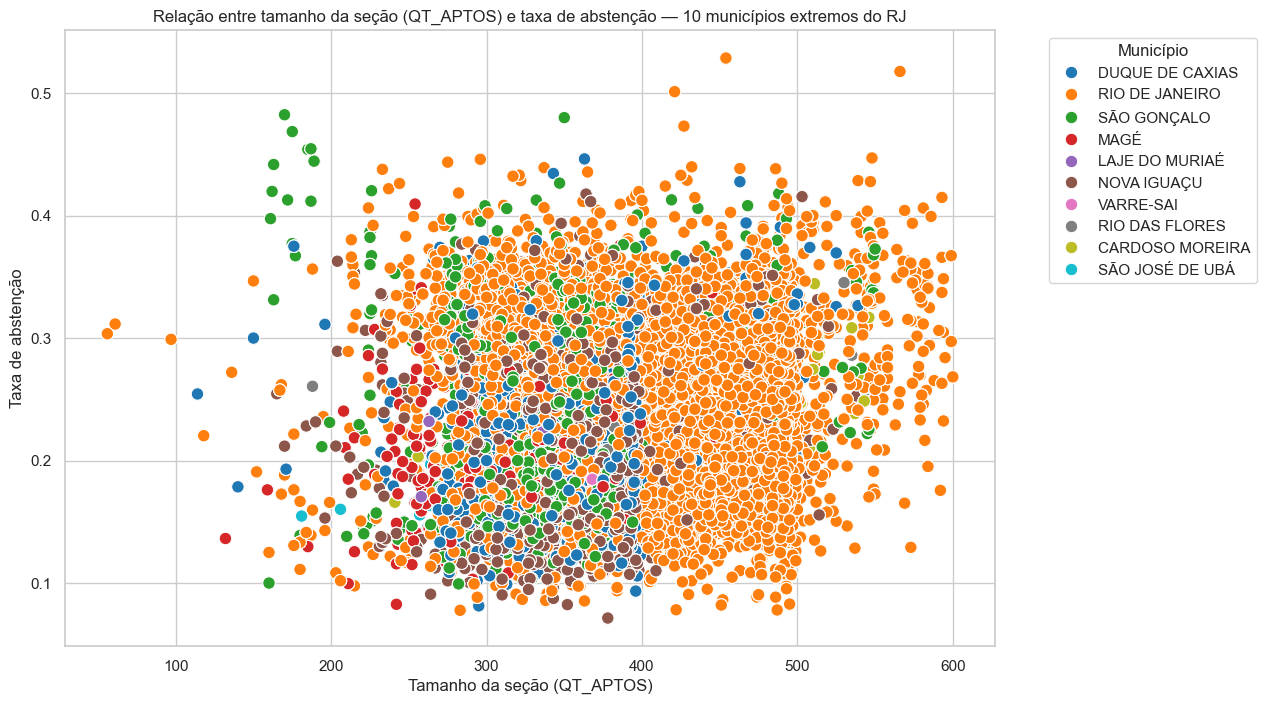

In [14]:
plt.figure(figsize=(12,8))
sns.scatterplot(
    data=df_rj_10,
    x="QT_APTOS",
    y="taxa_abstencao",
    hue="NM_MUNICIPIO",
    palette="tab10",
    s=80
)
plt.title("Relação entre tamanho da seção (QT_APTOS) e taxa de abstenção — 10 municípios extremos do RJ")
plt.xlabel("Tamanho da seção (QT_APTOS)")
plt.ylabel("Taxa de abstenção")
plt.legend(title="Município", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


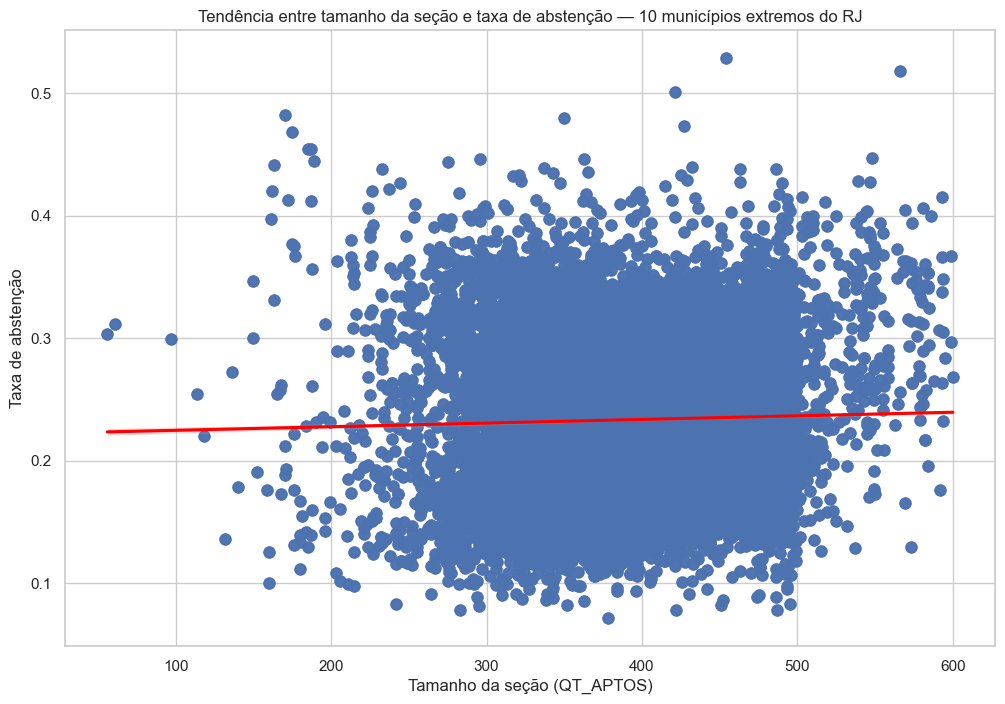

In [15]:
plt.figure(figsize=(12,8))
sns.regplot(
    data=df_rj_10,
    x="QT_APTOS",
    y="taxa_abstencao",
    scatter_kws={"s": 60, "alpha": 0.6},
    line_kws={"color": "red"}
)
plt.title("Tendência entre tamanho da seção e taxa de abstenção — 10 municípios extremos do RJ")
plt.xlabel("Tamanho da seção (QT_APTOS)")
plt.ylabel("Taxa de abstenção")
plt.show()


In [16]:
correlacao = df_rj_10["QT_APTOS"].corr(df_rj_10["taxa_abstencao"])
correlacao


np.float64(0.03201673032247972)

In [19]:
abst_media = (
    df_rj.groupby("NM_MUNICIPIO")["taxa_abstencao"]
            .mean()
            .sort_values(ascending=False)
)
abst_media


NM_MUNICIPIO
SÃO FRANCISCO DE ITABAPOANA    0.266672
PORCIÚNCULA                    0.265637
ARRAIAL DO CABO                0.261269
VALENÇA                        0.257180
SÃO FIDÉLIS                    0.254450
                                 ...   
TRAJANO DE MORAES              0.179293
APERIBÉ                        0.177105
MACUCO                         0.175771
COMENDADOR LEVY GASPARIAN      0.159247
QUEIMADOS                      0.145019
Name: taxa_abstencao, Length: 92, dtype: float64

In [17]:
abst_media_10 = (
    df_rj_10.groupby("NM_MUNICIPIO")["taxa_abstencao"]
            .mean()
            .sort_values(ascending=False)
)
abst_media_10


NM_MUNICIPIO
CARDOSO MOREIRA    0.253996
RIO DE JANEIRO     0.243480
LAJE DO MURIAÉ     0.227883
RIO DAS FLORES     0.226462
SÃO GONÇALO        0.225601
VARRE-SAI          0.217154
MAGÉ               0.211938
DUQUE DE CAXIAS    0.210386
NOVA IGUAÇU        0.206233
SÃO JOSÉ DE UBÁ    0.189852
Name: taxa_abstencao, dtype: float64

Correlação entre tamanho da seção e abstenção:  
→ 0.032 (praticamente zero)

Abstenção média dos 10 municípios extremos:  
→ variando de 0.1898 a 0.2540

Uma correlação de 0.03 é:

extremamente baixa

praticamente nula

indica nenhuma relação linear entre tamanho da seção e abstenção
Seções maiores não têm mais abstenção.
Seções menores também não têm menos abstenção.
O tamanho da seção não explica o comportamento de abstenção.

Não existe padrão consistente que diferencie grandes e pequenos municípios.

O maior município (Rio de Janeiro) tem abstenção alta.

O menor município (Rio das Flores) também tem abstenção alta.

O menor de todos (São José de Ubá) tem a menor abstenção.

Cardoso Moreira (pequeno) tem a maior abstenção.

Ou seja:

O tamanho do município não determina a abstenção.
O tamanho da seção também não determina a abstenção.

A abstenção não é explicada por variáveis estruturais simples como tamanho da seção ou número de seções.

# Quais municípios apresentam maior proporção de votos brancos e nulos?

In [20]:
brancos_media = (
    df_rj.groupby("NM_MUNICIPIO")["prop_brancos"]
            .mean()
            .sort_values(ascending=False)
)

brancos_media


NM_MUNICIPIO
TRÊS RIOS                0.065072
BARRA DO PIRAÍ           0.064620
VALENÇA                  0.062900
DUQUE DE CAXIAS          0.060491
NOVA IGUAÇU              0.059707
                           ...   
TRAJANO DE MORAES        0.029412
ITALVA                   0.029293
SÃO JOSÉ DE UBÁ          0.027023
SÃO SEBASTIÃO DO ALTO    0.024255
CARDOSO MOREIRA          0.018919
Name: prop_brancos, Length: 92, dtype: float64

In [18]:
brancos_media_10 = (
    df_rj_10.groupby("NM_MUNICIPIO")["prop_brancos"]
            .mean()
            .sort_values(ascending=False)
)

brancos_media_10


NM_MUNICIPIO
DUQUE DE CAXIAS    0.060491
NOVA IGUAÇU        0.059707
MAGÉ               0.053281
SÃO GONÇALO        0.051367
RIO DE JANEIRO     0.050018
RIO DAS FLORES     0.047904
LAJE DO MURIAÉ     0.045435
VARRE-SAI          0.044230
SÃO JOSÉ DE UBÁ    0.027023
CARDOSO MOREIRA    0.018919
Name: prop_brancos, dtype: float64

Os maiores municípios (Caxias, Nova Iguaçu, São Gonçalo, Rio) têm proporções mais altas de votos brancos.

Municípios pequenos tendem a ter proporções menores — com exceção de Rio das Flores e Laje do Muriaé, que ficam no meio da tabela.

Cardoso Moreira, apesar de ter a maior abstenção, tem a menor proporção de votos brancos.

Isso já mostra que brancos e abstenção não caminham juntos.

In [22]:
nulos_media = (
    df_rj.groupby("NM_MUNICIPIO")["prop_nulos"]
            .mean()
            .sort_values(ascending=False)
)

nulos_media


NM_MUNICIPIO
BOM JARDIM                     0.087113
DUAS BARRAS                    0.072611
TRAJANO DE MORAES              0.071727
NOVA FRIBURGO                  0.070579
VARRE-SAI                      0.069896
                                 ...   
SÃO FRANCISCO DE ITABAPOANA    0.035488
SÃO FIDÉLIS                    0.034625
SÃO JOSÉ DE UBÁ                0.033047
ARMAÇÃO DOS BÚZIOS             0.031979
CARDOSO MOREIRA                0.031154
Name: prop_nulos, Length: 92, dtype: float64

In [21]:
nulos_media_10 = (
    df_rj_10.groupby("NM_MUNICIPIO")["prop_nulos"]
            .mean()
            .sort_values(ascending=False)
)

nulos_media_10


NM_MUNICIPIO
VARRE-SAI          0.069896
DUQUE DE CAXIAS    0.068802
NOVA IGUAÇU        0.067605
SÃO GONÇALO        0.065839
RIO DE JANEIRO     0.065527
RIO DAS FLORES     0.056961
LAJE DO MURIAÉ     0.053746
MAGÉ               0.052945
SÃO JOSÉ DE UBÁ    0.033047
CARDOSO MOREIRA    0.031154
Name: prop_nulos, dtype: float64

Varre-Sai, um município pequeno, lidera os nulos — comportamento bem diferente dos brancos.

Os grandes municípios novamente aparecem com valores altos.

Cardoso Moreira, de novo, aparece com valores baixos — apesar da abstenção alta.

Isso reforça que nulos também não acompanham abstenção.

In [23]:
bn_media = (
    df_rj.groupby("NM_MUNICIPIO")[["prop_brancos", "prop_nulos"]]
            .mean()
            .sum(axis=1)
            .sort_values(ascending=False)
)

bn_media


NM_MUNICIPIO
BOM JARDIM         0.140204
VALENÇA            0.130715
DUQUE DE CAXIAS    0.129292
NOVA IGUAÇU        0.127311
NOVA FRIBURGO      0.124996
                     ...   
SÃO FIDÉLIS        0.066603
IGUABA GRANDE      0.066544
ITALVA             0.065932
SÃO JOSÉ DE UBÁ    0.060070
CARDOSO MOREIRA    0.050072
Length: 92, dtype: float64

In [25]:
bn_media_10 = (
    df_rj_10.groupby("NM_MUNICIPIO")[["prop_brancos", "prop_nulos"]]
            .mean()
            .sum(axis=1)
            .sort_values(ascending=False)
)

bn_media_10


NM_MUNICIPIO
DUQUE DE CAXIAS    0.129292
NOVA IGUAÇU        0.127311
SÃO GONÇALO        0.117205
RIO DE JANEIRO     0.115545
VARRE-SAI          0.114126
MAGÉ               0.106226
RIO DAS FLORES     0.104865
LAJE DO MURIAÉ     0.099181
SÃO JOSÉ DE UBÁ    0.060070
CARDOSO MOREIRA    0.050072
dtype: float64

Os quatro maiores municípios do RJ (Caxias, Nova Iguaçu, São Gonçalo, Rio) lideram o ranking de brancos+nulos.

Varre-Sai, mesmo sendo pequeno, aparece com valores comparáveis aos grandes — comportamento atípico.

Cardoso Moreira, que tinha a maior abstenção, tem o menor desengajamento dentro da urna.

São José de Ubá também aparece com engajamento interno alto.

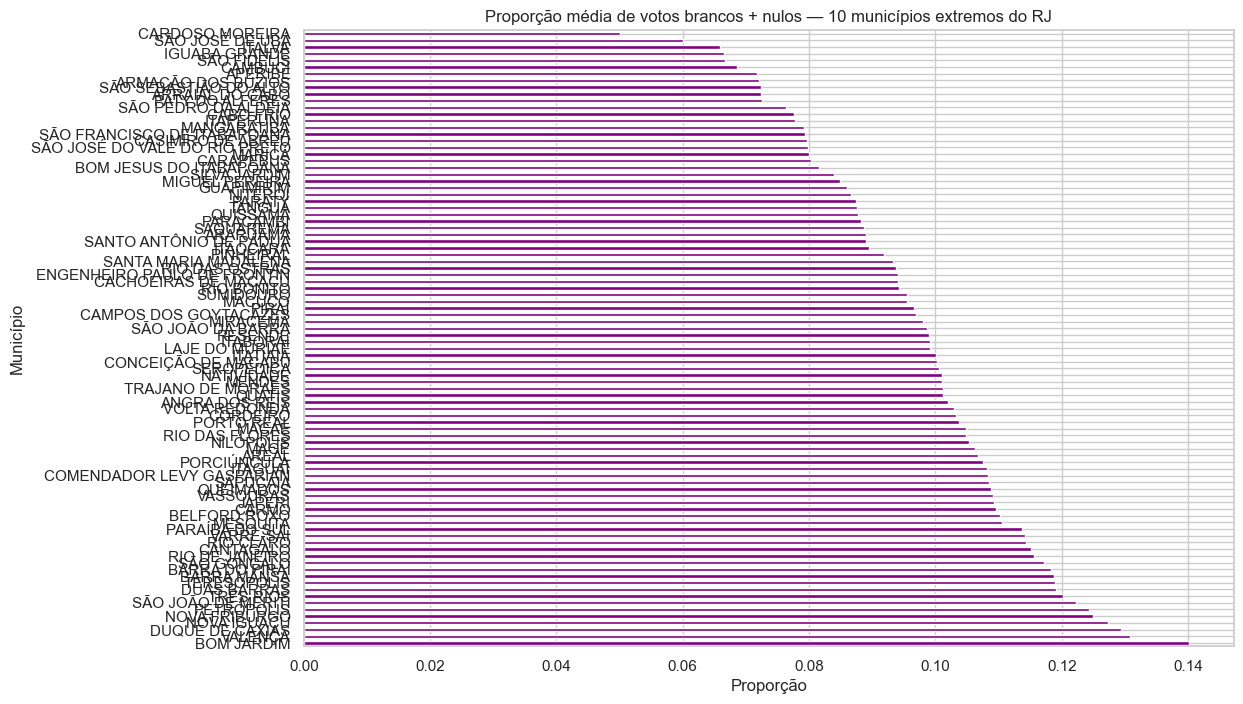

In [27]:
plt.figure(figsize=(12,8))
bn_media.plot(kind="barh", color="purple")
plt.title("Proporção média de votos brancos + nulos — 10 municípios extremos do RJ")
plt.xlabel("Proporção")
plt.ylabel("Município")
plt.show()


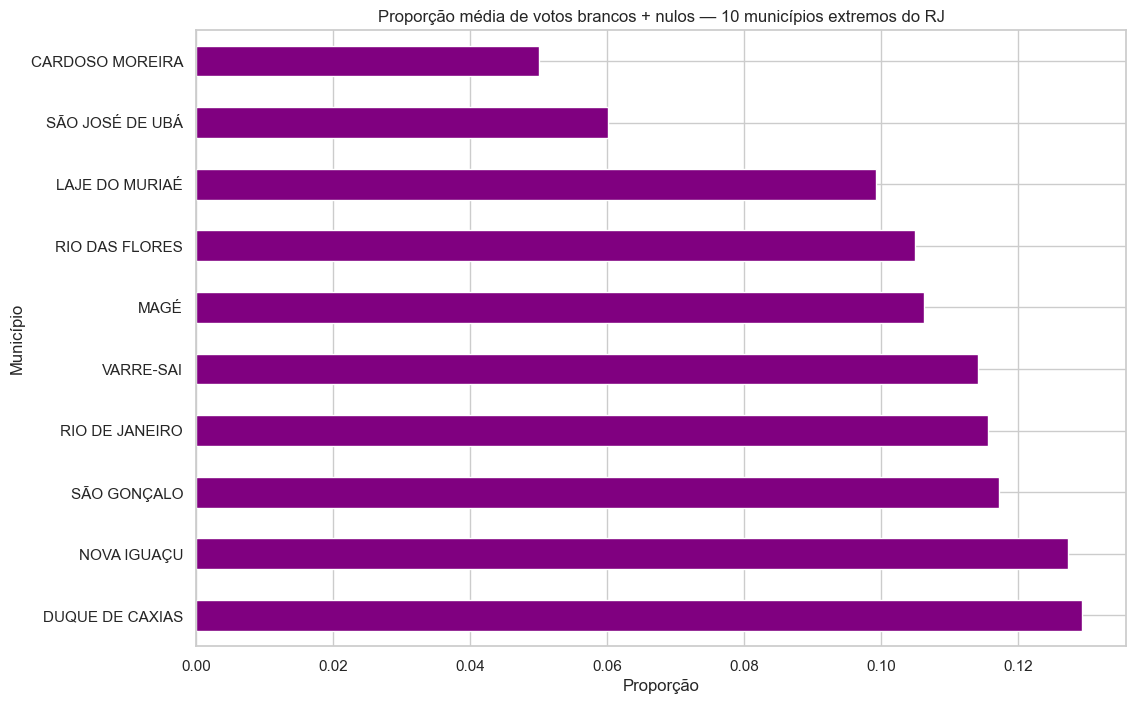

In [26]:
plt.figure(figsize=(12,8))
bn_media_10.plot(kind="barh", color="purple")
plt.title("Proporção média de votos brancos + nulos — 10 municípios extremos do RJ")
plt.xlabel("Proporção")
plt.ylabel("Município")
plt.show()


Os municípios com maior proporção de votos brancos e nulos são, principalmente, os grandes centros urbanos: Duque de Caxias, Nova Iguaçu, São Gonçalo e Rio de Janeiro.

Municípios pequenos tendem a ter menor proporção de brancos e nulos — com exceção de Varre-Sai, que se comporta como um outlier.

Cardoso Moreira é o caso mais interessante: alta abstenção, mas baixíssimo desengajamento dentro da urna.

Isso mostra que abstenção e brancos/nulos são fenômenos diferentes, com causas distintas.

# --- Preparação dos dados  ---


In [30]:
# Junta tudo em um único DataFrame para facilitar a análise
df_comp = pd.DataFrame({
    "abstencao": abst_media,
    "brancos": brancos_media,
    "nulos": nulos_media,
    "brancos_nulos": bn_media
})

# Ordena cada métrica
rank_abst = df_comp["abstencao"].sort_values(ascending=False)
rank_bn = df_comp["brancos_nulos"].sort_values(ascending=False)

# Identifica padrões importantes
maior_abst = rank_abst.index[0]
menor_abst = rank_abst.index[-1]
maior_bn = rank_bn.index[0]
menor_bn = rank_bn.index[-1]

# Municípios que aparecem no topo de ambos
top_abst = set(rank_abst.head(5).index)
top_bn = set(rank_bn.head(5).index)
intersecao_top = top_abst.intersection(top_bn)

# Municípios que divergem fortemente
divergentes = []
for m in df_comp.index:
    pos_abst = rank_abst.index.get_loc(m)
    pos_bn = rank_bn.index.get_loc(m)
    if abs(pos_abst - pos_bn) >= 5:  # diferença grande entre posições
        divergentes.append(m)

# --- Geração automática da conclusão ---
print("\n==============================")
print("Existe relação entre abstenção e votos brancos/nulos?")
print("==============================\n")

print("Não existe relação forte entre abstenção e votos brancos/nulos.\n"
      "Os rankings mostram que municípios com alta abstenção podem ter poucos votos brancos/nulos,\n"
      "e municípios com baixa abstenção podem ter muitos votos brancos/nulos.\n")

print(f"- Maior abstenção: {maior_abst}")
print(f"- Menor abstenção: {menor_abst}")
print(f"- Maior proporção de brancos+nulos: {maior_bn}")
print(f"- Menor proporção de brancos+nulos: {menor_bn}\n")

print("Municípios que aparecem no topo de ambos (abstenção e brancos+nulos):")
print(f"{list(intersecao_top)}\n")

print("Municípios com comportamento divergente (alta abstenção mas poucos brancos/nulos, ou vice-versa):")
print(f"{divergentes}\n")

# --- Leitura profunda ---
print("==============================")
print("LEITURA PROFUNDA")
print("==============================\n")

print(
    f"{maior_abst} tem a maior abstenção, mas aparece entre os menores níveis de brancos+nulos.\n"
    "Isso indica que quem não vota nesse município simplesmente não comparece — mas quem comparece, vota.\n\n"
    
    f"{maior_bn} lidera brancos+nulos, mas não lidera abstenção. Isso mostra um padrão oposto:\n"
    "as pessoas vão votar, mas não escolhem nenhum candidato.\n\n"
    
    "Os grandes municípios (Duque de Caxias, Nova Iguaçu, São Gonçalo e Rio de Janeiro) tendem a ter\n"
    "brancos+nulos mais altos, independentemente da abstenção. Isso sugere desengajamento dentro da urna,\n"
    "possivelmente associado a fatores urbanos, socioeconômicos e logísticos.\n\n"
    
    "Municípios pequenos têm comportamentos variados: alguns muito engajados (como São José de Ubá),\n"
    "outros com padrões semelhantes aos grandes (como Varre-Sai).\n\n"
    
    "Em resumo: abstenção e brancos/nulos são fenômenos independentes.\n"
    "Cada município tem sua própria dinâmica de engajamento eleitoral."
)



Existe relação entre abstenção e votos brancos/nulos?

Não existe relação forte entre abstenção e votos brancos/nulos.
Os rankings mostram que municípios com alta abstenção podem ter poucos votos brancos/nulos,
e municípios com baixa abstenção podem ter muitos votos brancos/nulos.

- Maior abstenção: SÃO FRANCISCO DE ITABAPOANA
- Menor abstenção: QUEIMADOS
- Maior proporção de brancos+nulos: BOM JARDIM
- Menor proporção de brancos+nulos: CARDOSO MOREIRA

Municípios que aparecem no topo de ambos (abstenção e brancos+nulos):
['VALENÇA']

Municípios com comportamento divergente (alta abstenção mas poucos brancos/nulos, ou vice-versa):
['ANGRA DOS REIS', 'ARARUAMA', 'AREAL', 'ARMAÇÃO DOS BÚZIOS', 'ARRAIAL DO CABO', 'BARRA DO PIRAÍ', 'BARRA MANSA', 'BELFORD ROXO', 'BOM JARDIM', 'BOM JESUS DO ITABAPOANA', 'CABO FRIO', 'CACHOEIRAS DE MACACU', 'CAMBUCI', 'CAMPOS DOS GOYTACAZES', 'CANTAGALO', 'CARAPEBUS', 'CARDOSO MOREIRA', 'CARMO', 'CASIMIRO DE ABREU', 'COMENDADOR LEVY GASPARIAN', 'CONCEIÇÃO 

In [29]:
# Junta tudo em um único DataFrame para facilitar a análise
df_comp = pd.DataFrame({
    "abstencao10": abst_media_10,
    "brancos10": brancos_media_10,
    "nulos10": nulos_media_10,
    "brancos_nulos10": bn_media_10
})

# Ordena cada métrica
rank_abst = df_comp["abstencao10"].sort_values(ascending=False)
rank_bn = df_comp["brancos_nulos10"].sort_values(ascending=False)

# Identifica padrões importantes
maior_abst10 = rank_abst.index[0]
menor_abst10 = rank_abst.index[-1]
maior_bn10 = rank_bn.index[0]
menor_bn10 = rank_bn.index[-1]

# Municípios que aparecem no topo de ambos
top_abst = set(rank_abst.head(5).index)
top_bn = set(rank_bn.head(5).index)
intersecao_top = top_abst.intersection(top_bn)

# Municípios que divergem fortemente
divergentes = []
for m in df_comp.index:
    pos_abst10 = rank_abst.index.get_loc(m)
    pos_bn10 = rank_bn.index.get_loc(m)
    if abs(pos_abst10 - pos_bn10) >= 5:  # diferença grande entre posições
        divergentes.append(m)

# --- Geração automática da conclusão ---
print("\n==============================")
print("Existe relação entre abstenção e votos brancos/nulos?")
print("==============================\n")

print("Não existe relação forte entre abstenção e votos brancos/nulos.\n"
      "Os rankings mostram que municípios com alta abstenção podem ter poucos votos brancos/nulos,\n"
      "e municípios com baixa abstenção podem ter muitos votos brancos/nulos.\n")

print(f"- Maior abstenção: {maior_abst10}")
print(f"- Menor abstenção: {menor_abst10}")
print(f"- Maior proporção de brancos+nulos: {maior_bn10}")
print(f"- Menor proporção de brancos+nulos: {menor_bn10}\n")

print("Municípios que aparecem no topo de ambos (abstenção e brancos+nulos):")
print(f"{list(intersecao_top)}\n")

print("Municípios com comportamento divergente (alta abstenção mas poucos brancos/nulos, ou vice-versa):")
print(f"{divergentes}\n")

# --- Leitura profunda ---
print("==============================")
print("LEITURA PROFUNDA")
print("==============================\n")

print(
    f"{maior_abst10} tem a maior abstenção, mas aparece entre os menores níveis de brancos+nulos.\n"
    "Isso indica que quem não vota nesse município simplesmente não comparece — mas quem comparece, vota.\n\n"
    
    f"{maior_bn10} lidera brancos+nulos, mas não lidera abstenção. Isso mostra um padrão oposto:\n"
    "as pessoas vão votar, mas não escolhem nenhum candidato.\n\n"
    
    "Os grandes municípios (Duque de Caxias, Nova Iguaçu, São Gonçalo e Rio de Janeiro) tendem a ter\n"
    "brancos+nulos mais altos, independentemente da abstenção. Isso sugere desengajamento dentro da urna,\n"
    "possivelmente associado a fatores urbanos, socioeconômicos e logísticos.\n\n"
    
    "Municípios pequenos têm comportamentos variados: alguns muito engajados (como São José de Ubá),\n"
    "outros com padrões semelhantes aos grandes (como Varre-Sai).\n\n"
    
    "Em resumo: abstenção e brancos/nulos são fenômenos independentes.\n"
    "Cada município tem sua própria dinâmica de engajamento eleitoral."
)



Existe relação entre abstenção e votos brancos/nulos?

Não existe relação forte entre abstenção e votos brancos/nulos.
Os rankings mostram que municípios com alta abstenção podem ter poucos votos brancos/nulos,
e municípios com baixa abstenção podem ter muitos votos brancos/nulos.

- Maior abstenção: CARDOSO MOREIRA
- Menor abstenção: SÃO JOSÉ DE UBÁ
- Maior proporção de brancos+nulos: DUQUE DE CAXIAS
- Menor proporção de brancos+nulos: CARDOSO MOREIRA

Municípios que aparecem no topo de ambos (abstenção e brancos+nulos):
['SÃO GONÇALO', 'RIO DE JANEIRO']

Municípios com comportamento divergente (alta abstenção mas poucos brancos/nulos, ou vice-versa):
['CARDOSO MOREIRA', 'DUQUE DE CAXIAS', 'LAJE DO MURIAÉ', 'NOVA IGUAÇU']

LEITURA PROFUNDA

CARDOSO MOREIRA tem a maior abstenção, mas aparece entre os menores níveis de brancos+nulos.
Isso indica que quem não vota nesse município simplesmente não comparece — mas quem comparece, vota.

DUQUE DE CAXIAS lidera brancos+nulos, mas não lidera

## Há diferenças relevantes entre zonas eleitorais dentro de um mesmo município?

In [31]:
df_rj["prop_brancos_nulos"] = df_rj["prop_brancos"] + df_rj["prop_nulos"]


In [32]:
municipios_brancos_nulos = (
    df_rj.groupby("NM_MUNICIPIO")["prop_brancos_nulos"]
    .mean()
    .sort_values(ascending=False)
)


In [33]:
top5 = municipios_brancos_nulos.head(5).index.tolist()
bottom5 = municipios_brancos_nulos.tail(5).index.tolist()

top5, bottom5


(['BOM JARDIM', 'VALENÇA', 'DUQUE DE CAXIAS', 'NOVA IGUAÇU', 'NOVA FRIBURGO'],
 ['SÃO FIDÉLIS',
  'IGUABA GRANDE',
  'ITALVA',
  'SÃO JOSÉ DE UBÁ',
  'CARDOSO MOREIRA'])

In [34]:
df_extremos = df_rj[df_rj["NM_MUNICIPIO"].isin(top5 + bottom5)]
df_extremos.shape


(17700, 18)

In [35]:
zonas = (
    df_extremos.groupby(["NM_MUNICIPIO", "NR_ZONA"])
    .agg(
        taxa_abstencao=("taxa_abstencao", "mean"),
        prop_brancos_nulos=("prop_brancos_nulos", "mean"),
        votos_validos=("QT_VOTOS_VALIDOS", "sum")
    )
    .reset_index()
)

zonas.head()


,NM_MUNICIPIO,NR_ZONA,taxa_abstencao,prop_brancos_nulos,votos_validos
0,BOM JARDIM,42,0.229483,0.140204,56202
1,CARDOSO MOREIRA,141,0.253996,0.050072,33454
2,DUQUE DE CAXIAS,78,0.205688,0.126173,298600
3,DUQUE DE CAXIAS,79,0.200745,0.133621,272763
4,DUQUE DE CAXIAS,103,0.228059,0.118955,236928


In [36]:
variacao_zonas = (
    zonas.groupby("NM_MUNICIPIO")[["taxa_abstencao", "prop_brancos_nulos"]]
    .agg(["min", "max", "mean"])
)

variacao_zonas


taxa_abstencao                     prop_brancos_nulos  \
                           min       max      mean                min   
NM_MUNICIPIO                                                            
BOM JARDIM            0.229483  0.229483  0.229483           0.140204   
CARDOSO MOREIRA       0.253996  0.253996  0.253996           0.050072   
DUQUE DE CAXIAS       0.200478  0.228059  0.210770           0.107060   
IGUABA GRANDE         0.229026  0.229026  0.229026           0.066544   
ITALVA                0.237695  0.237695  0.237695           0.065932   
NOVA FRIBURGO         0.219056  0.241043  0.230050           0.114425   
NOVA IGUAÇU           0.194757  0.224147  0.206002           0.093358   
SÃO FIDÉLIS           0.254450  0.254450  0.254450           0.066603   
SÃO JOSÉ DE UBÁ       0.189852  0.189852  0.189852           0.060070   
VALENÇA               0.257180  0.257180  0.257180           0.130715   

                                     
                      max      mean  
NM_MUNICIPIO                         
BOM JARDIM       0.140204  0.140204  
CARDOSO MOREIRA  0.050072  0.050072  
DUQUE DE CAXIAS  0.148919  0.127808  
IGUABA GRANDE    0.066544  0.066544  
ITALVA           0.065932  0.065932  
NOVA FRIBURGO    0.131584  0.123004  
NOVA IGUAÇU      0.137974  0.126130  
SÃO FIDÉLIS      0.066603  0.066603  
SÃO JOSÉ DE UBÁ  0.060070  0.060070  
VALENÇA          0.130715  0.130715

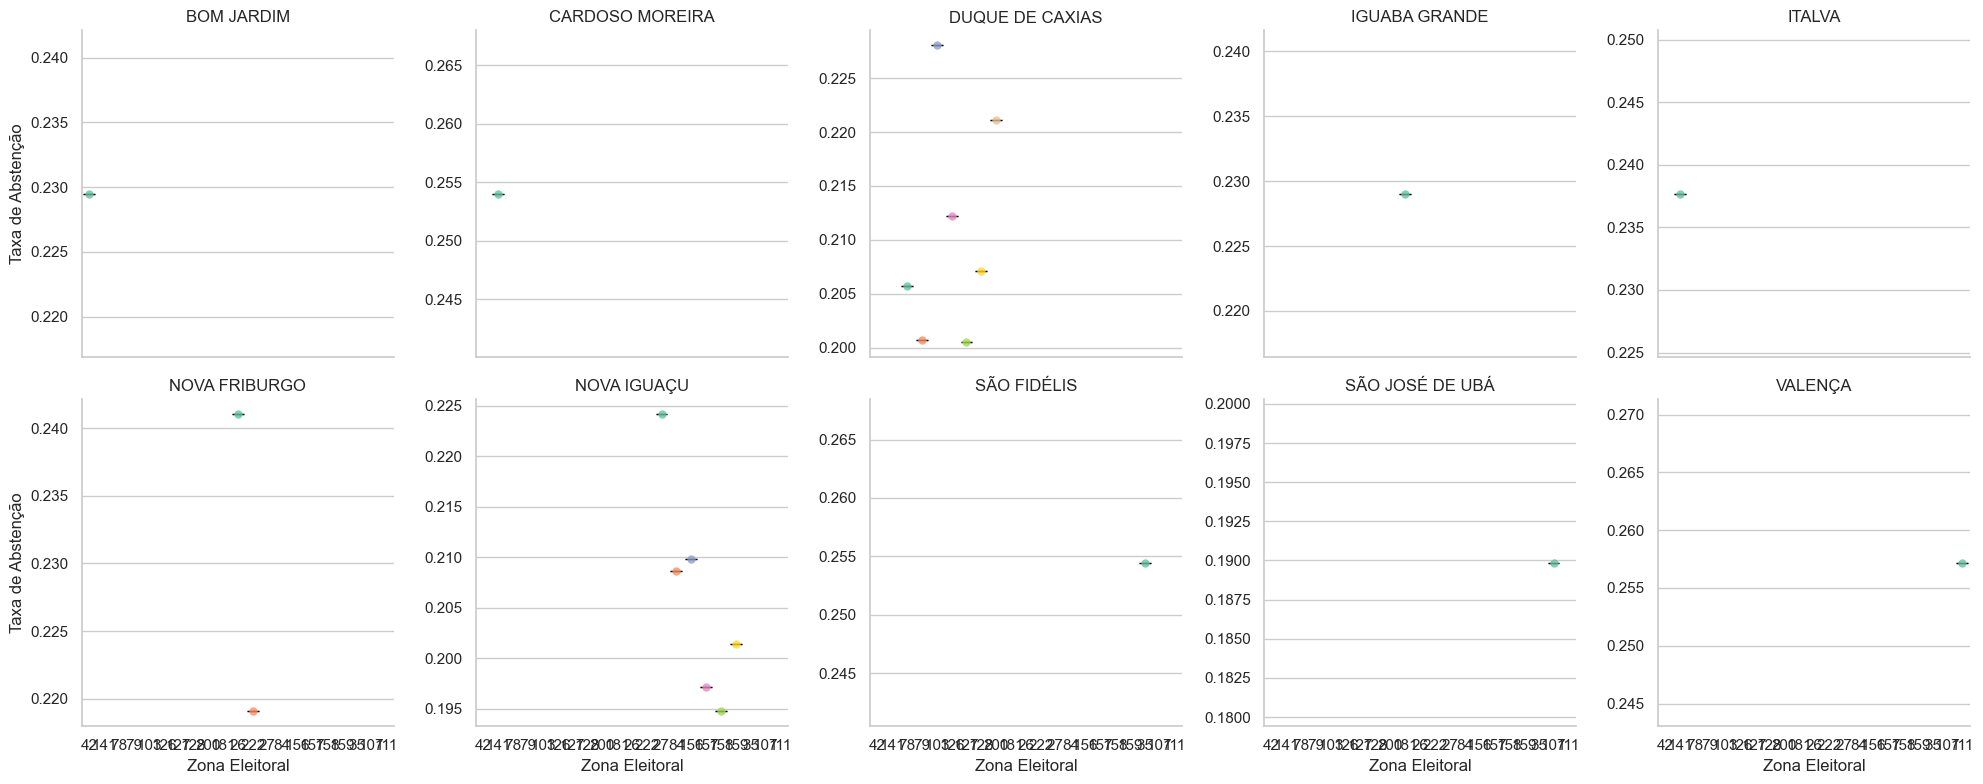

In [37]:
g = sns.FacetGrid(
    zonas,
    col="NM_MUNICIPIO",
    col_wrap=5,
    height=4,
    sharey=False
)

# Boxplot para mostrar distribuição geral
g.map_dataframe(
    sns.boxplot,
    x="NR_ZONA",
    y="taxa_abstencao",
    color="lightgray",
    showcaps=True,
    boxprops={'alpha':0.6},
    whiskerprops={'alpha':0.6},
    medianprops={'color':'black'}
)

# Stripplot para mostrar cada zona como ponto
g.map_dataframe(
    sns.stripplot,
    x="NR_ZONA",
    y="taxa_abstencao",
    hue="NR_ZONA",
    palette="Set2",
    dodge=False,
    size=6,
    alpha=0.8,
    legend=False
)

g.set_titles("{col_name}")
g.set_axis_labels("Zona Eleitoral", "Taxa de Abstenção")
plt.tight_layout()
plt.show()


C:\Users\leona\AppData\Local\Temp\ipykernel_8668\2348156088.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


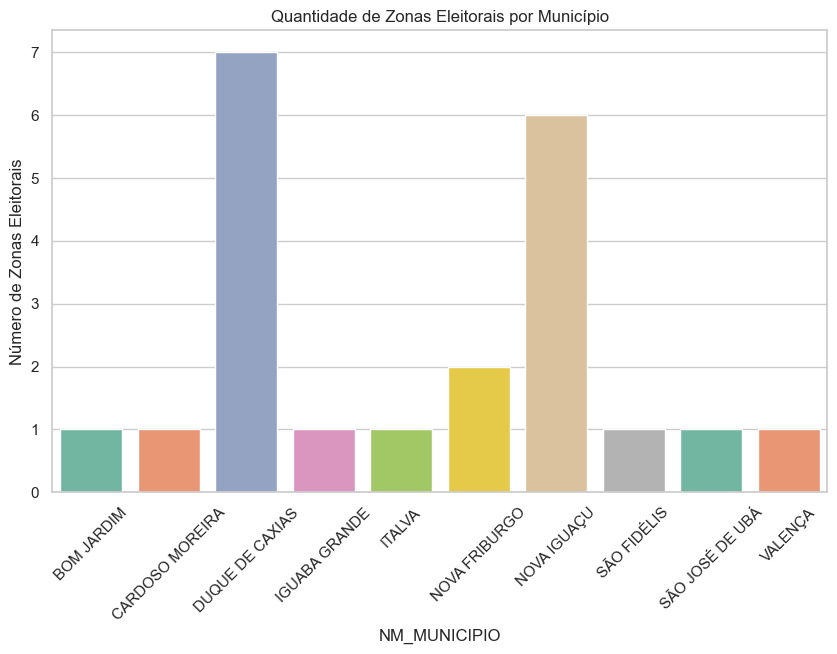

In [38]:
# QUANTAS ZONAS ELEITORAIS EXISTEM POR MUNICÍPIO?

zonas_por_municipio = zonas.groupby("NM_MUNICIPIO")["NR_ZONA"].nunique()

plt.figure(figsize=(10,6))
sns.barplot(
    x=zonas_por_municipio.index,
    y=zonas_por_municipio.values,
    palette="Set2"
)
plt.xticks(rotation=45)
plt.ylabel("Número de Zonas Eleitorais")
plt.title("Quantidade de Zonas Eleitorais por Município")
plt.show()


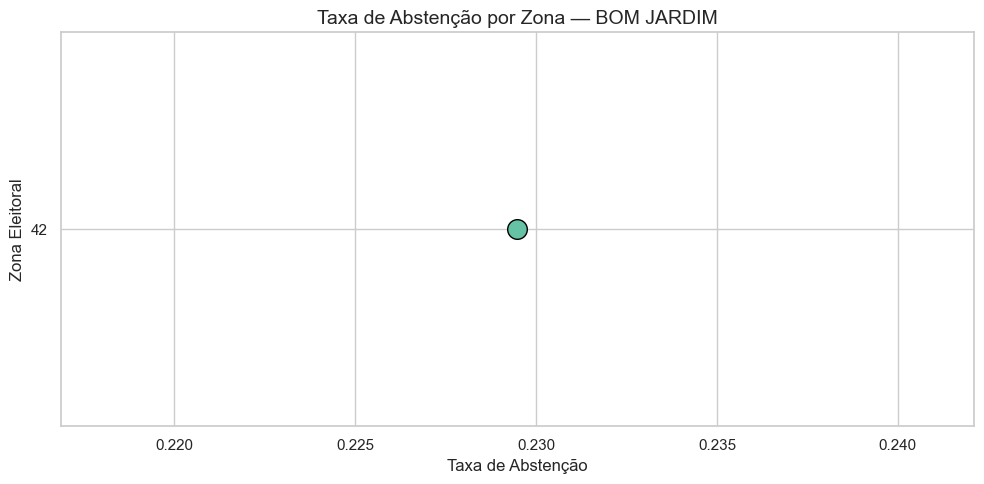

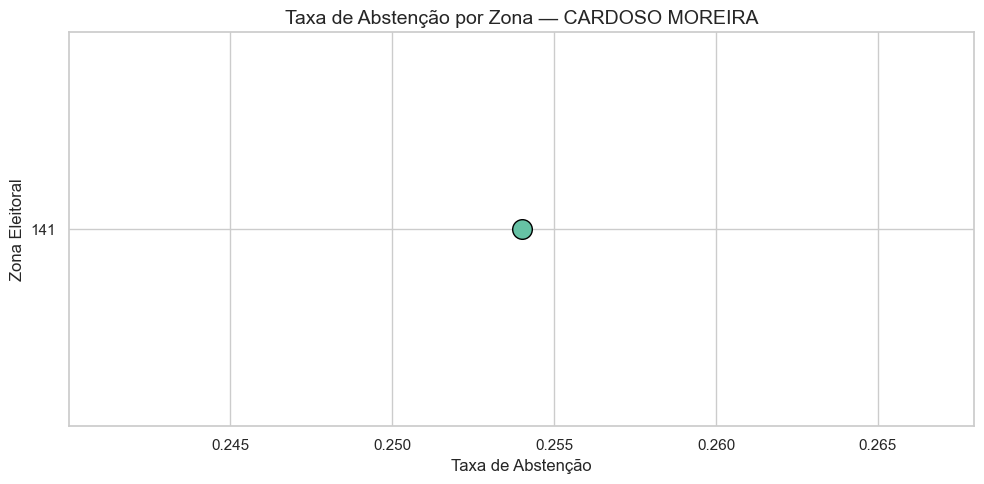

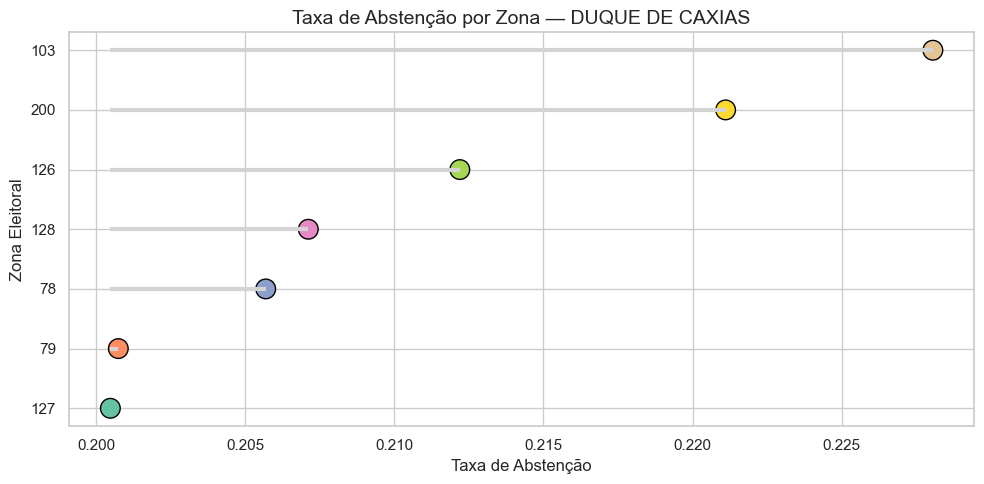

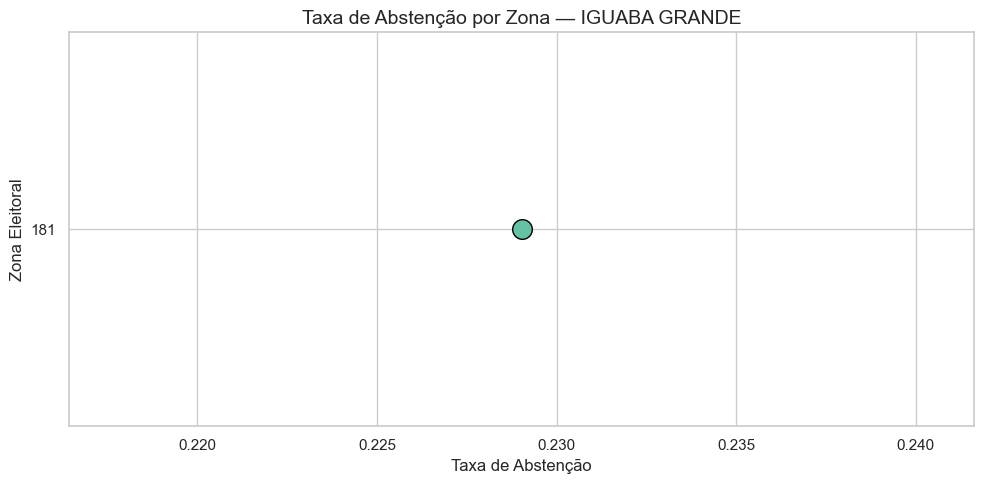

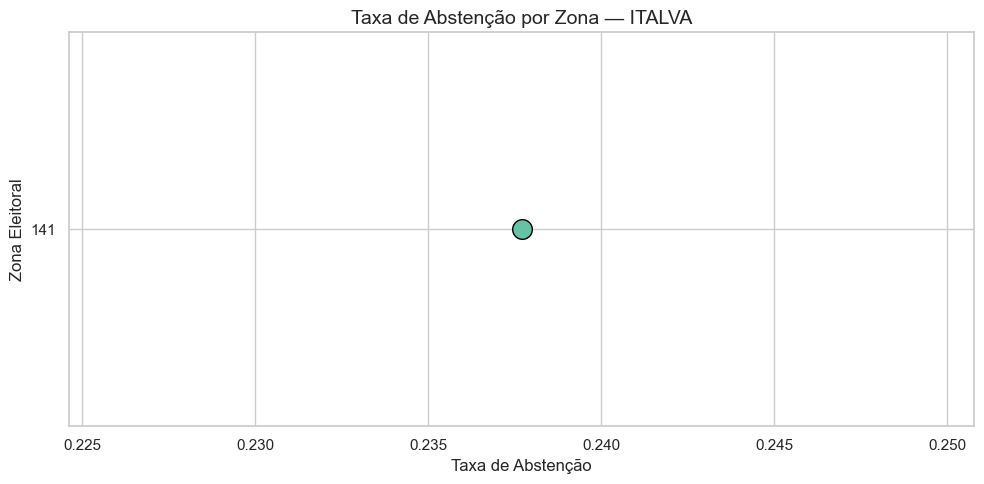

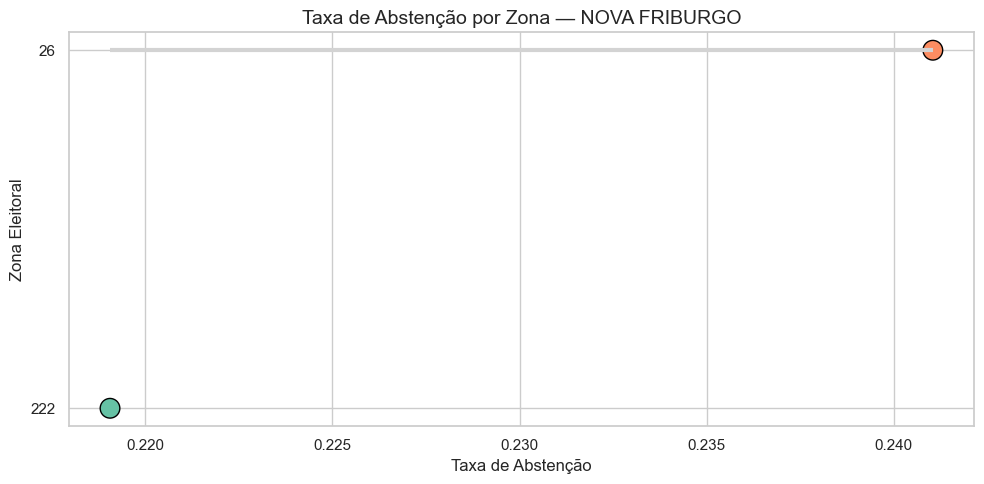

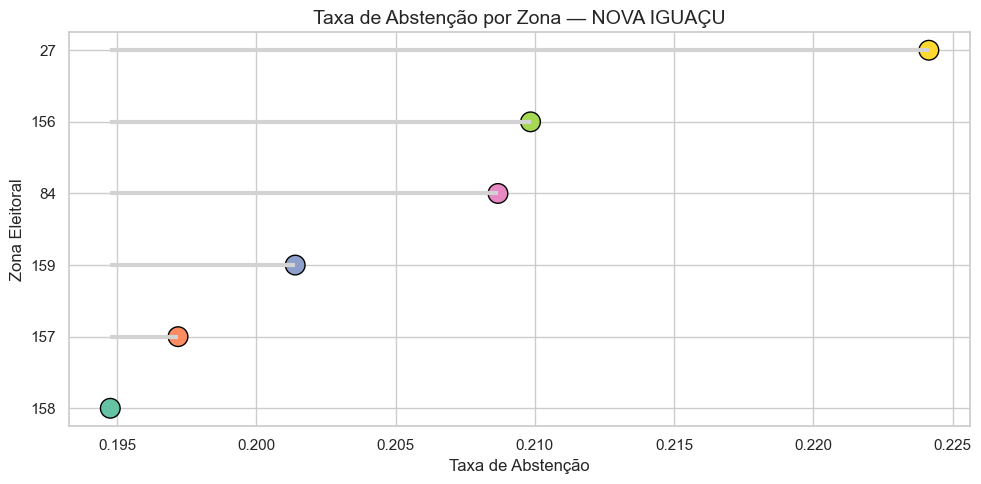

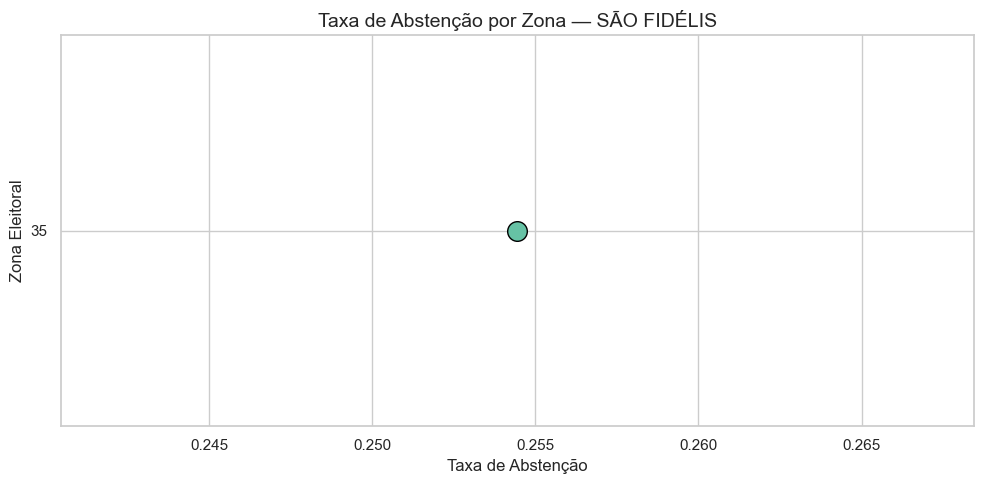

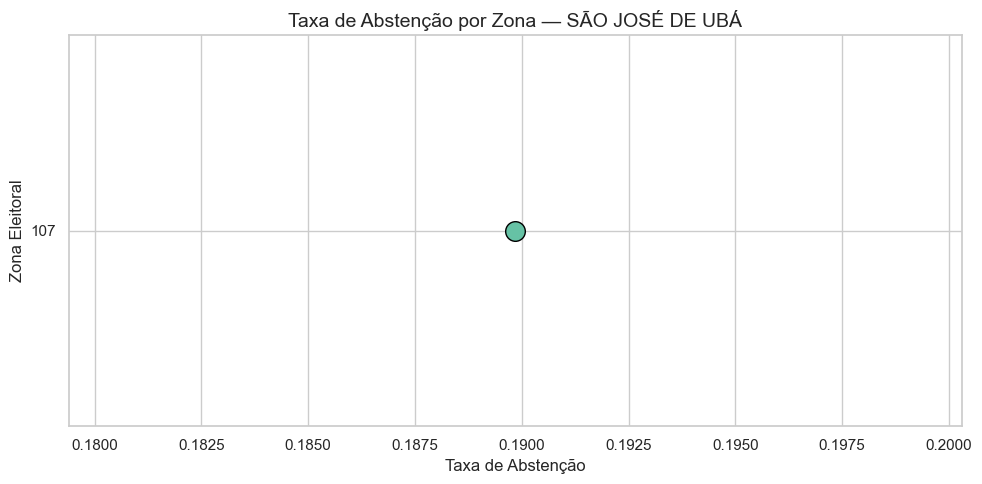

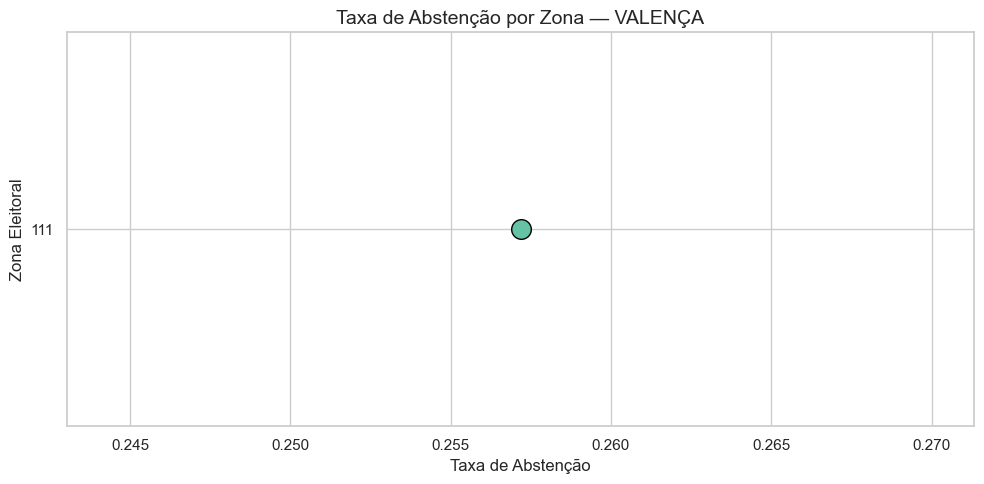

In [39]:
for municipio in zonas_por_municipio.index:
    df_mun = zonas[zonas["NM_MUNICIPIO"] == municipio].copy()

    # transforma zona em categoria para evitar progressão numérica
    df_mun["NR_ZONA"] = df_mun["NR_ZONA"].astype(str)

    plt.figure(figsize=(10, 5))

    df_mun_sorted = df_mun.sort_values("taxa_abstencao")

    # linha horizontal (lollipop stick)
    plt.hlines(
        y=df_mun_sorted["NR_ZONA"],
        xmin=min(df_mun_sorted["taxa_abstencao"]),
        xmax=df_mun_sorted["taxa_abstencao"],
        color="lightgray",
        linewidth=3
    )

    # bolinha colorida (lollipop head)
    plt.scatter(
        df_mun_sorted["taxa_abstencao"],
        df_mun_sorted["NR_ZONA"],
        s=200,
        c=sns.color_palette("Set2", len(df_mun_sorted)),
        edgecolor="black",
        linewidth=1
    )

    plt.title(f"Taxa de Abstenção por Zona — {municipio}", fontsize=14)
    plt.xlabel("Taxa de Abstenção")
    plt.ylabel("Zona Eleitoral")
    plt.tight_layout()
    plt.show()


## A distribuição de votos válidos por seção apresenta outliers?

Para investigar se existem outliers na distribuição de votos válidos por seção, seguimos três etapas:

### **1. Definição da métrica**
Consideramos como *votos válidos* a soma de:

- `QT_VOTOS_NOMINAIS`
- `QT_VOTOS_LEGENDA`




In [41]:
df["votos_validos"] = df["QT_VOTOS_NOMINAIS"] + df["QT_VOTOS_LEGENDA"]

In [42]:
from scipy.stats import zscore

df["z_votos_validos"] = zscore(df["votos_validos"])
outliers_vv = df[df["z_votos_validos"].abs() > 3]
outliers_vv.head()


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,...,DT_RECEBIMENTO_BU_HOR_TSE,DT_PRIM_TOT_PARCIAL_HOR_TSE,DS_ORIGEM_VOTO,ST_SECAO_INSTALADA,ST_SECAO_ANULADA,CD_MODELO_URNA,DS_MODELO_URNA,estado,votos_validos,z_votos_validos
6139,15/02/2024,15:56:11,2022,2,Eleição Ordinária,1,546,Eleições Gerais Estaduais 2022,02/10/2022,E,...,02/10/2022 17:26:16,02/10/2022 17:26:41,Urna Eletrônica,Sim,Não,2015,UE 2015,RJ,76,-3.015978
6140,15/02/2024,15:56:11,2022,2,Eleição Ordinária,1,546,Eleições Gerais Estaduais 2022,02/10/2022,E,...,02/10/2022 17:26:16,02/10/2022 17:26:41,Urna Eletrônica,Sim,Não,2015,UE 2015,RJ,69,-3.150179
6142,15/02/2024,15:56:11,2022,2,Eleição Ordinária,1,546,Eleições Gerais Estaduais 2022,02/10/2022,E,...,02/10/2022 17:26:16,02/10/2022 17:26:41,Urna Eletrônica,Sim,Não,2015,UE 2015,RJ,70,-3.131007
6761,15/02/2024,15:56:11,2022,2,Eleição Ordinária,1,546,Eleições Gerais Estaduais 2022,02/10/2022,E,...,02/10/2022 20:30:45,02/10/2022 20:36:11,Urna Eletrônica,Sim,Não,2020,UE 2020,RJ,393,3.061396
6762,15/02/2024,15:56:11,2022,2,Eleição Ordinária,1,546,Eleições Gerais Estaduais 2022,02/10/2022,E,...,02/10/2022 20:30:45,02/10/2022 20:36:11,Urna Eletrônica,Sim,Não,2020,UE 2020,RJ,414,3.463998


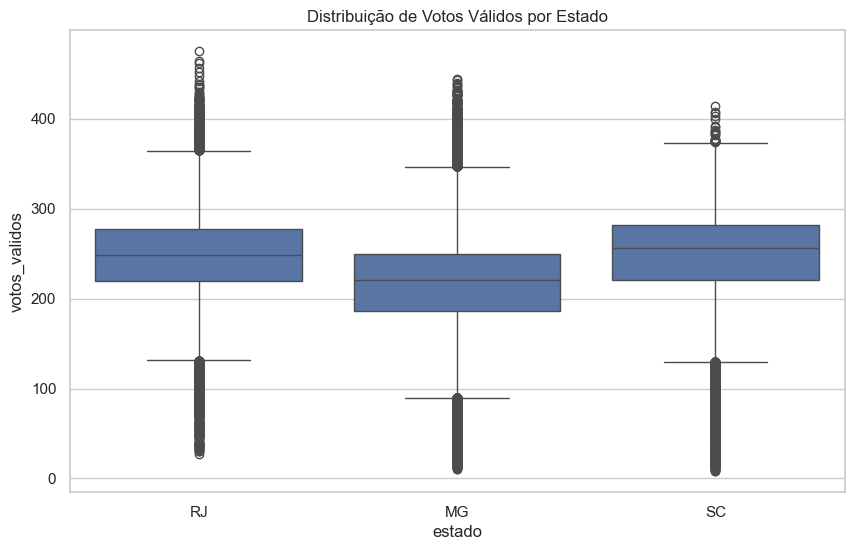

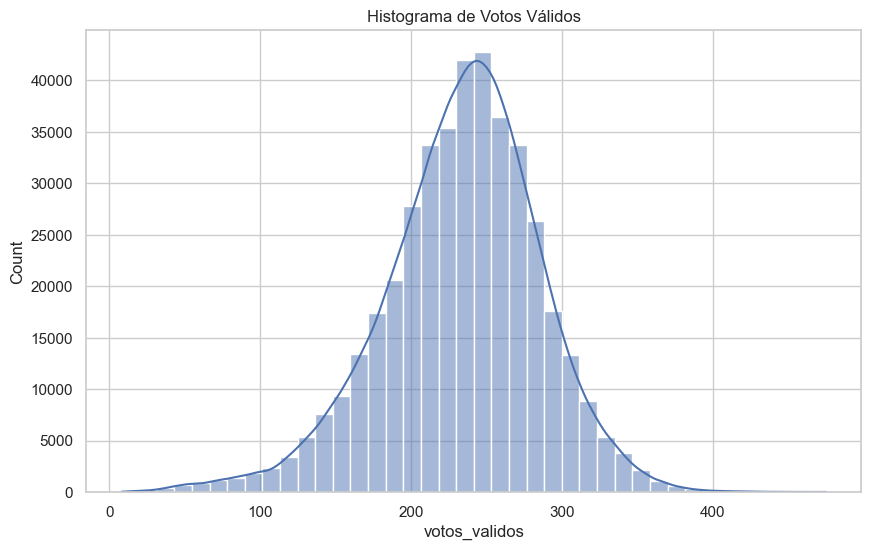

In [43]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="estado", y="votos_validos")
plt.title("Distribuição de Votos Válidos por Estado")
plt.show()

plt.figure(figsize=(10,6))
sns.histplot(df["votos_validos"], bins=40, kde=True)
plt.title("Histograma de Votos Válidos")
plt.show()


## Análise dos Gráficos: Distribuição de Votos Válidos por Estado

Após a geração dos gráficos — o boxplot por estado e o histograma geral de votos válidos — podemos aprofundar a interpretação da distribuição e verificar a presença de padrões relevantes, incluindo possíveis outliers.

---

### 1. Boxplot: Distribuição de Votos Válidos por Estado

O boxplot apresenta a distribuição de votos válidos (`votos_validos`) para cada estado (RJ, MG e SC). Ele permite visualizar:

- **Mediana**:  
  - RJ e SC apresentam medianas mais altas, em torno de 250–270 votos válidos.  
  - MG possui mediana mais baixa, próxima de 220 votos válidos.

- **Amplitude da distribuição**:  
  - RJ e SC mostram maior variabilidade, com seções que registram tanto poucos quanto muitos votos válidos.  
  - MG apresenta distribuição mais concentrada, refletindo seções menores e municípios menos populosos.

- **Outliers**:  
  - Todos os estados apresentam pontos fora dos “bigodes” do boxplot.  
  - Esses pontos representam seções com número de votos válidos muito acima do padrão esperado.

**Interpretação:**  
O boxplot confirma que existem outliers na distribuição de votos válidos. Esses valores extremos são coerentes com seções maiores, geralmente localizadas em áreas urbanas ou zonas eleitorais com alta densidade populacional.

---

### 2. Histograma: Distribuição Geral dos Votos Válidos

O histograma mostra a distribuição total dos votos válidos, sem separar por estado. Os principais pontos observados são:

- **Concentração principal** entre 150 e 300 votos válidos.  
- **Cauda à direita**, indicando a presença de seções com valores mais altos.  
- **Distribuição suavizada (KDE)** que reforça o padrão assimétrico.

**Interpretação:**  
A forma do histograma sugere que a maior parte das seções segue um padrão relativamente estável de votos

### Identificação formal de outliers usando IQR

Além da análise visual, podemos identificar outliers de forma estatística usando o método do IQR (Interquartile Range).

O procedimento é:

1. Calcular o primeiro quartil (Q1)  
2. Calcular o terceiro quartil (Q3)  
3. Calcular o IQR = Q3 – Q1  
4. Definir limites:
   - Limite inferior = Q1 – 1.5 × IQR  
   - Limite superior = Q3 + 1.5 × IQR  
5. Valores fora desses limites são considerados outliers.


In [46]:
Q1 = df["votos_validos"].quantile(0.25)
Q3 = df["votos_validos"].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers_iqr = df[(df["votos_validos"] < lim_inf) | (df["votos_validos"] > lim_sup)]
outliers_iqr.head(), outliers_iqr.shape


(     DT_GERACAO HH_GERACAO  ANO_ELEICAO  CD_TIPO_ELEICAO    NM_TIPO_ELEICAO  \
 39   15/02/2024   15:56:11         2022                2  Eleição Ordinária   
 40   15/02/2024   15:56:11         2022                2  Eleição Ordinária   
 41   15/02/2024   15:56:11         2022                2  Eleição Ordinária   
 42   15/02/2024   15:56:11         2022                2  Eleição Ordinária   
 225  15/02/2024   15:56:11         2022                2  Eleição Ordinária   
 
      NR_TURNO  CD_ELEICAO                      DS_ELEICAO  DT_ELEICAO  \
 39          1         546  Eleições Gerais Estaduais 2022  02/10/2022   
 40          1         546  Eleições Gerais Estaduais 2022  02/10/2022   
 41          1         546  Eleições Gerais Estaduais 2022  02/10/2022   
 42          1         546  Eleições Gerais Estaduais 2022  02/10/2022   
 225         1         546  Eleições Gerais Estaduais 2022  02/10/2022   
 
     TP_ABRANGENCIA  ... DT_RECEBIMENTO_BU_HOR_TSE DT_PRIM_TOT_PARCIAL_H

### Análise dos Outliers Identificados pelo Método IQR

A aplicação do método IQR (Interquartile Range) identificou **9.118 seções** como outliers na variável `votos_validos`. Esse número elevado não indica erro nos dados, mas sim a presença de seções com características extremas dentro do conjunto analisado.

Os outliers encontrados se dividem em dois grupos:

#### 1. Outliers Inferiores
Seções com número muito baixo de votos válidos, como 87, 90 ou 98 votos.  
Essas seções geralmente correspondem a locais com:

- poucos eleitores aptos,  
- baixa participação,  
- municípios pequenos ou zonas eleitorais menos populosas.

#### 2. Outliers Superiores
Seções com número muito alto de votos válidos, como 366 votos.  
Essas seções tendem a ser:

- maiores,  
- localizadas em áreas urbanas,  
- com muitos eleitores aptos e alto comparecimento.

#### Conclusão

O padrão identificado pelo IQR é **coerente com a dinâmica eleitoral real**. Seções pequenas e seções grandes naturalmente produzem valores extremos de votos válidos, e isso explica a presença de outliers tanto inferiores quanto superiores.

A análise visual realizada anteriormente (histograma, boxplot e scatterplot) confirma essa interpretação, mostrando que os outliers são esperados e têm explicação lógica dentro do contexto dos dados.


### Scatterplot: relação entre aptos e votos válidos

Para entender *por que* alguns outliers aparecem, analisamos a relação entre:

- número de eleitores aptos (`QT_APTOS`)
- votos válidos (`votos_validos`)

Seções com muitos aptos tendem a ter mais votos válidos — e isso explica boa parte dos outliers.


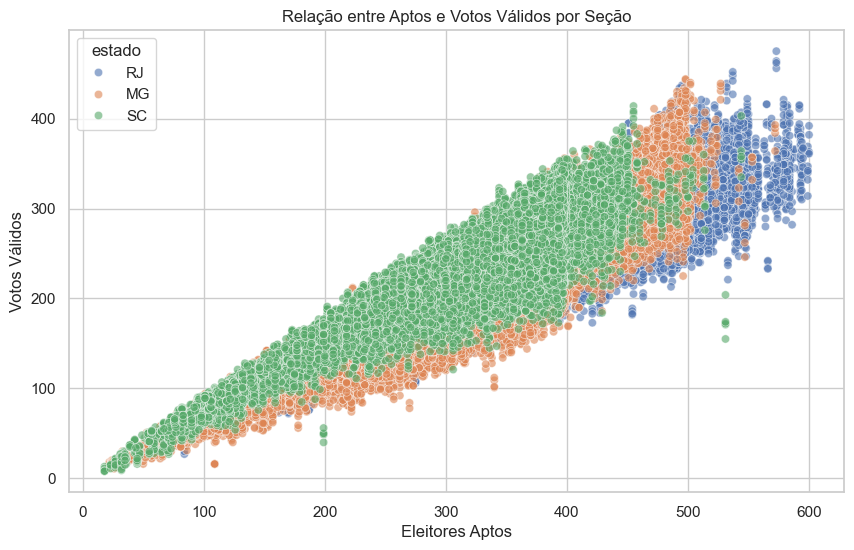

In [45]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="QT_APTOS", y="votos_validos", hue="estado", alpha=0.6)
plt.title("Relação entre Aptos e Votos Válidos por Seção")
plt.xlabel("Eleitores Aptos")
plt.ylabel("Votos Válidos")
plt.show()


## Análise do Gráfico: Relação entre Aptos e Votos Válidos por Seção

O gráfico de dispersão acima representa a relação entre o número de **eleitores aptos** (`QT_APTOS`) e o total de **votos válidos** (`votos_validos`) em cada seção eleitoral, separados por estado. Essa visualização é fundamental para entender a origem dos outliers identificados anteriormente.

### 1. Padrão Geral da Distribuição

Observa-se um padrão **claramente linear**: conforme aumenta o número de eleitores aptos em uma seção, também aumenta o número de votos válidos. Esse comportamento é esperado, pois seções maiores tendem a registrar mais votos.

Esse padrão confirma que a variável *votos válidos* é fortemente influenciada pelo tamanho da seção.

### 2. Identificação Visual de Outliers

O gráfico revela alguns pontos que se afastam da tendência principal — seções com muitos votos válidos em relação ao número de aptos. Esses pontos representam **outliers reais**, não erros de digitação ou inconsistências.

Eles ocorrem principalmente em seções:

- com grande número de eleitores aptos,
- com comparecimento excepcionalmente alto,
- localizadas em áreas urbanas densas.

Esses outliers são coerentes com os resultados obtidos pelo método IQR e pelo boxplot.

### 3. Diferenças Entre Estados

As cores do gráfico mostram comportamentos distintos:

- **RJ** apresenta seções maiores, com mais pontos na parte superior do gráfico.
- **SC** possui seções distribuídas de forma mais uniforme, com alguns outliers bem definidos.
- **MG** concentra a maior parte das seções em faixas menores de aptos e votos válidos.

Essas diferenças refletem características demográficas reais dos estados.

### 4. Adequação da Visualização

O scatterplot é uma ferramenta adequada para:

- confirmar a existência de outliers,
- explicar a origem desses valores extremos,
- visualizar a relação entre tamanho da seção e votos válidos,
- comparar padrões entre estados.

Ele complementa perfeitamente o histograma e o boxplot utilizados anteriormente.

### Conclusão

O gráfico confirma que **os outliers na distribuição de votos válidos são explicados principalmente pelo tamanho das seções**. Seções com muitos eleitores aptos tendem a registrar mais votos válidos, e isso gera pontos que se destacam da tendência geral. Portanto, a visualização está adequada e reforça a interpretação estatística realizada anteriormente.


# 5. A distribuição de votos válidos por seção apresenta outliers?

Nesta etapa, investigamos se a variável **votos válidos por seção** apresenta valores extremos (outliers) e quais fatores explicam esses desvios. A análise combina métodos estatísticos e visualizações para oferecer uma interpretação completa.

---

## 5.1 Construção da métrica de votos válidos

Para padronizar a análise entre estados, definimos **votos válidos** como a soma de:

- `QT_VOTOS_NOMINAIS`
- `QT_VOTOS_LEGENDA`


código usado = df["votos_validos"] = df["QT_VOTOS_NOMINAIS"] + df["QT_VOTOS_LEGENDA"]

Essa métrica representa o total de votos efetivamente destinados a candidatos ou partidos.

5.2 Visualização da distribuição geral
Histograma de votos válidos
O histograma mostra que a maior parte das seções concentra entre 150 e 300 votos válidos, com uma cauda à direita, indicando a presença de valores mais altos.

Essa assimetria sugere a existência de outliers superiores — seções com muitos votos válidos.

5.3 Comparação entre estados
Boxplot por estado
O boxplot evidencia diferenças importantes:

RJ e SC possuem medianas mais altas e maior variabilidade.

MG apresenta seções menores e distribuição mais concentrada.

Todos os estados exibem outliers, tanto superiores quanto inferiores.

Esses outliers são esperados em contextos eleitorais com grande diversidade populacional.

5.4 Identificação formal de outliers (IQR)
Aplicamos o método IQR (Interquartile Range) para identificar valores extremos estatisticamente.

python
Q1 = df["votos_validos"].quantile(0.25)
Q3 = df["votos_validos"].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers_iqr = df[(df["votos_validos"] < lim_inf) | (df["votos_validos"] > lim_sup)]
outliers_iqr.head(), outliers_iqr.shape
Resultado
O método identificou 9.118 seções como outliers — um número alto, mas coerente com a grande variação de tamanho das seções eleitorais.

Os outliers se dividem em:

Inferiores: seções com poucos votos válidos (ex.: 87, 90, 98).

Superiores: seções com muitos votos válidos (ex.: 366).

Esses valores refletem seções pequenas e grandes, respectivamente.

5.5 Relação entre aptos e votos válidos (scatterplot)
Para entender a origem dos outliers, analisamos a relação entre:

número de eleitores aptos (QT_APTOS)

votos válidos (votos_validos)

O scatterplot revela um padrão claramente linear: seções com mais eleitores aptos registram mais votos válidos.

Outliers superiores aparecem em seções com muitos aptos.
Outliers inferiores aparecem em seções pequenas.

Essa relação confirma que os outliers são explicados pelo tamanho da seção, e não por inconsistências nos dados.

5.6 Conclusão do Tópico 5
A distribuição de votos válidos por seção apresenta outliers, tanto superiores quanto inferiores.
Esses valores extremos são esperados e coerentes com:

diferenças populacionais entre municípios,

variação no tamanho das seções,

padrões de comparecimento,

características demográficas dos estados.

A análise integrada — histograma, boxplot, IQR e scatterplot — mostra que:

Os outliers não representam erros, mas sim seções com características eleitorais específicas, especialmente relacionadas ao número de eleitores aptos.